# Titanic analysis

## Introduction

This analysis seeks to find relations between the variables that led to a higher survival rate. The main focus will be on if any specific patterns are found that resulted in a specific outcome (i.e survived or not)

The main variables that will be compared will be:
- Age
- Sex
- Class
- Deck
- and alone vs none alone passengers

In [511]:
# import modules
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
# import math

To start, I will first look through the dataset and check for any missing values and remove them, when appropriate, to ensure the results of the analysis are not skewed

In [512]:
# get a brief overview of the data used within the tables
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [513]:
# get the null values from each collumn
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

The 177 missing ages can either be filled with an average age or dropped. For this instance, dropping the rows is more appropriate. However, they will be dropped once the survival percent for the whole unchanged dataset has been found.

The null deck values will not be dropped yet. This is because they still contain valueable information in their other columns, when comparing between deck level and survival rates, these will be dropped to ensure a more accurate analysis. 

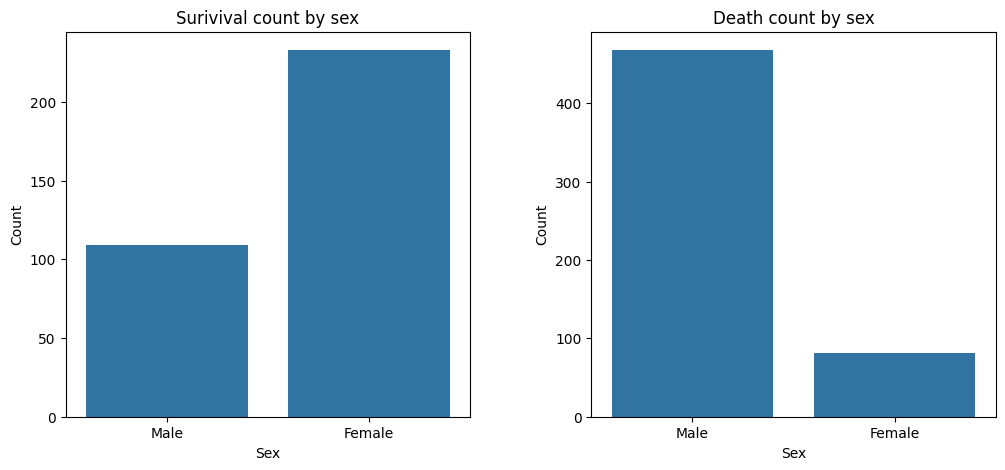

In [514]:
# create a canvas with 2 subplots
# 1 row, 2 cols
# width = 12, height = 5
# the figure contains the whole chart, the axes contains the seperate plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# add some space between the plots
plt.subplots_adjust(wspace=0.3)

# get the amount of survivors and deaths
survivors = titanic[titanic["survived"] == 1]
non_survivors = titanic[titanic["survived"] == 0]


# survivors["who"].value_counts()
# non_survivors["who"].value_counts()

# will be used to ensure both plots will be in the same order for easier comparison
order = ["male", "female"]

sns.countplot(data=survivors, x="sex", order=order, ax=axes[0])
axes[0].set_title("Surivival count by sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")
axes[0].set_xticks(["male","female"], ["Male", "Female"])

sns.countplot(data=non_survivors, x="sex", order=order, ax=axes[1])
axes[1].set_title("Death count by sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")
axes[1].set_xticks(["male","female"], ["Male", "Female"])


With these charts side by side, it is clear to see that females had a significantly higher rate of survival, despite there being less females overall. 

By having the second chart showing that not many females died, it shows a clear correlation that the ratio of survival for females was much higher. To confirm that, I will calculate the survival percentage. 

Survial percentage for men: 19%
Survial percentage for men: 74%


Text(0, 0.5, 'Survival Percentage')

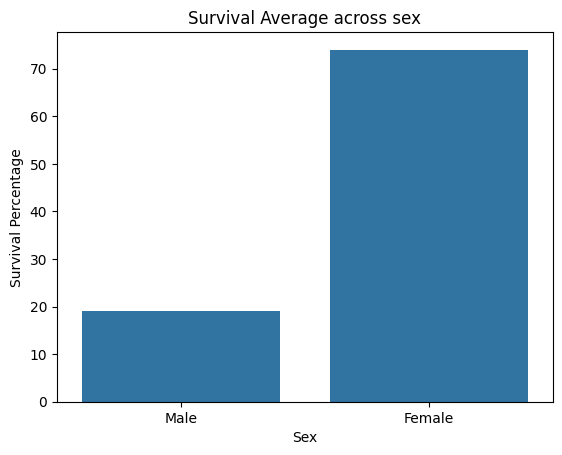

In [531]:
survival_percentage = titanic.groupby("sex")["survived"].mean()
survival_percentage_male = round(survival_percentage["male"] * 100)
survival_percentage_female = round(survival_percentage["female"] * 100)

# get the survival percentage and round it for easier viewing
print(f"Survial percentage for men: {survival_percentage_male}%")
print(f"Survial percentage for men: {survival_percentage_female}%")

sns.barplot(x=["Male", "Female"], y=[survival_percentage_male, survival_percentage_female])
plt.title("Survival Average across sex")
plt.xlabel("Sex")
plt.ylabel("Survival Percentage")

From the percentages, we can see that the above charts were accurate. Women were **55% more likely** to survive on the Titanic.

There could be many reasons for this, one of those reasons being chivalry and courtesy where women were allowed priority when evacuating the ship.

survived
0    549
1    342
Name: count, dtype: int64 38


Text(0.5, 1.0, 'Average survival rate vs female average survival rate')

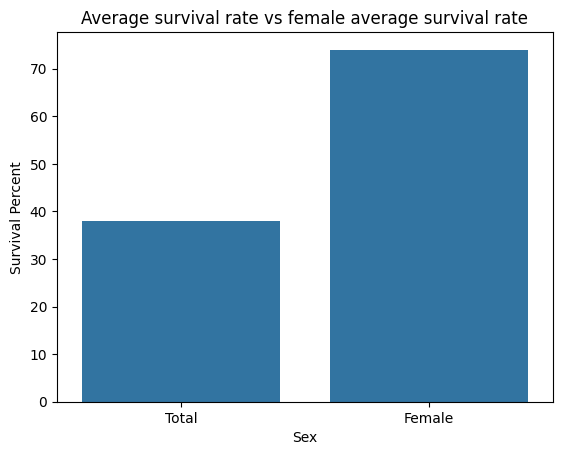

In [529]:
total_survivors = titanic["survived"].value_counts()
total_survivors_average = round(titanic["survived"].mean() * 100) 

print(total_survivors, total_survivors_average)


sns.barplot(x=["Total", "Female"], y=[total_survivors_average, survival_percentage_female])
plt.xlabel("Sex")
plt.ylabel("Survival Percent")
plt.title("Average survival rate vs female average survival rate")

Compared to the overall survival rate, women had nearly double the chance to survive which confirms our previous analysis. 

The first conclusion we can make from the dataset is that women had a significantly higher rate of survival. The reasons for this could vary, but judging by the time period, it is likely that women were seen as a higher priority when bringing passengers to safety. 

Now that we have got the overall survival rate, we can now drop the empty ages to further disect this dataset.

In [517]:
# remove the empty values

cleaned_df = titanic.dropna(subset=["age"])
cleaned_df["age"].isnull().value_counts()

age
False    714
Name: count, dtype: int64

By printing the null value count we can see that the null ages have successfully been removed. 

We can now begin using age to further disect this dataset

First, we will compare the survival rate across ages

In [518]:
cleaned_df.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False


Text(0.5, 0, 'Age')

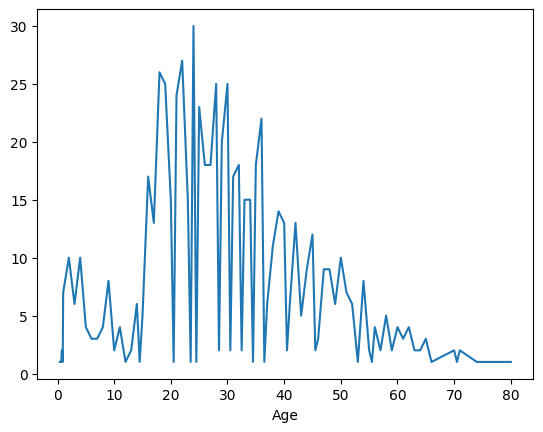

In [519]:
age_count = cleaned_df["age"].value_counts().sort_index()
# print(age_count)
sns.lineplot(x=age_count.index, y=age_count.values)
plt.xlabel("Age")

Looking at the line plot, it shows that most people aboard were middle aged, however, it is quite hard to infer the ages through a line plot. 

<Axes: xlabel='age', ylabel='Count'>

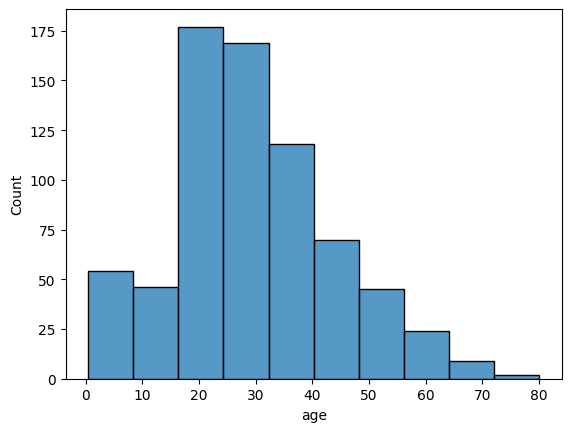

In [520]:
sns.histplot(data=cleaned_df, x="age", bins=10)

A histgram makes it much easier to group the average age of passengers. 

We can now see that there is mostly babies adn middle aged passengers with a sharp decline around of passengers over the age of 50

([<matplotlib.axis.XTick at 0x17e4cdf6060>,
 [Text(0.0, 0, 'Child'), Text(1.0, 0, 'Adult'), Text(2.0, 0, 'Senior')])

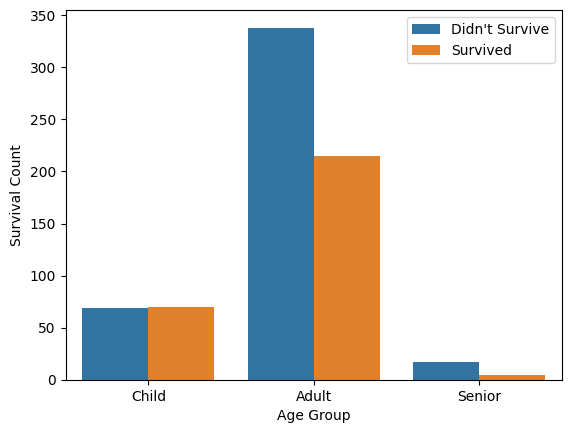

In [521]:
# create a new column to group ages into categories
cleaned_df["age_group"] = pd.cut(
    cleaned_df["age"], 
    bins=[0, 18, 60, 100], 
    labels=["child", "adult", "senior"])

sns.countplot(data=cleaned_df, x="age_group", hue="survived")
plt.xlabel("Age Group")
plt.ylabel("Survival Count")
plt.legend(["Didn't Survive", "Survived"])
plt.xticks(["child", "adult", "senior"], ["Child", "Adult", "Senior"])

Although it's clear to see that seniors had a very low survival rate, its hard to actually understand the relation between age group and survival rate. In order to understand better, the averages will be more useful

([<matplotlib.axis.XTick at 0x17e4ce6a5d0>,
 [Text(0.0, 0, 'Child'), Text(1.0, 0, 'Adult'), Text(2.0, 0, 'Senior')])

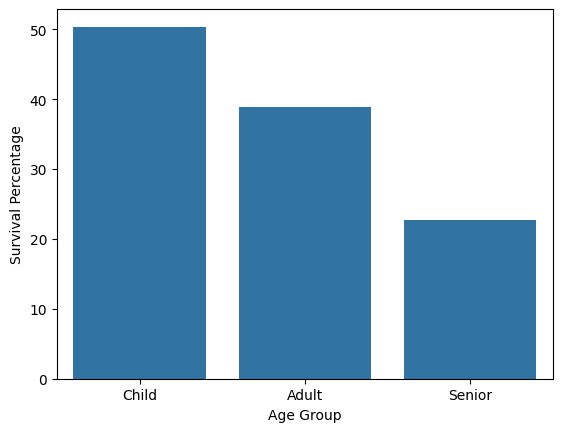

In [522]:
age_group_survival = cleaned_df.groupby("age_group")["survived"].mean() * 100 
age_group_survival = age_group_survival.reset_index()

sns.barplot(data=age_group_survival, x="age_group", y="survived")
plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")
plt.xticks(["child", "adult", "senior"], ["Child", "Adult", "Senior"])

Now we can see that children had the highest survival rate. This is likely due to children being taken as highest priority when escaping

This also shows that the survival rate for seniors and adults aren't actually as low as the original count plot showed. 

Now that we have this data, we can see within the age groups and see if Sex made a difference

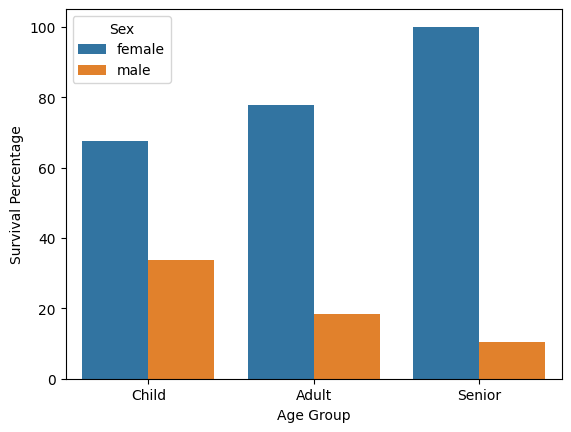

In [523]:
survival_rate_by_age_and_sex = cleaned_df.groupby(["age_group", "sex"])["survived"].mean() * 100
survival_rate_by_age_and_sex = survival_rate_by_age_and_sex.reset_index()

sns.barplot(data=survival_rate_by_age_and_sex, x="age_group", y="survived", hue="sex")
plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")
plt.xticks(["child", "adult", "senior"], ["Child", "Adult", "Senior"])
plt.legend(title="Sex")

We can now see that women are the predmenant survivors through all age groups, with the highest being in the senior age group, presumably becuase of the previously mentioned chivalry. 

    class  survived
0   First      66.0
1  Second      48.0
2   Third      24.0


Text(0, 0.5, 'Survival Percentage')

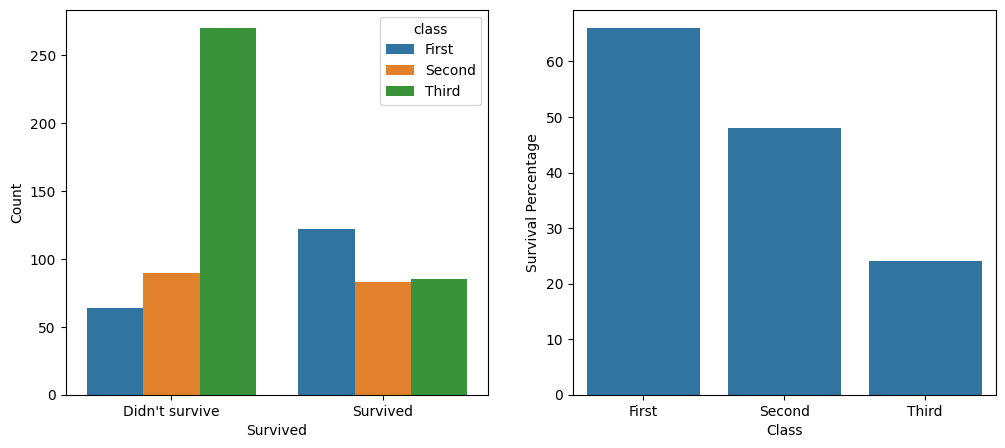

In [524]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

cleaned_df["class"].isnull().value_counts() # confirm no null values

class_survival_rate = cleaned_df.groupby(by="class")["survived"].value_counts().reset_index()
# print(class_survival_rate)

sns.barplot(data=class_survival_rate, x="survived", y="count", hue="class", ax=axes[0])
axes[0].set_xlabel("Survived")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1], ["Didn't survive", "Survived"])

# get the rounded averages
class_survival_rate_average = round(cleaned_df.groupby(by="class")["survived"].mean() * 100).reset_index()
print(class_survival_rate_average)

sns.barplot(data=class_survival_rate_average, x="class", y="survived")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Survival Percentage")


We can see from the charts above that class had a significant role in the survival rate. The higher a passengers class, the higher their survival rate was. This is likely due to higher paying passengers being treated as a higher priority than those who paid less

      sex   class  survived
0  female   First      96.0
1  female  Second      92.0
2  female   Third      46.0
3    male   First      40.0
4    male  Second      15.0
5    male   Third      15.0


Text(0, 0.5, 'Surival Average')

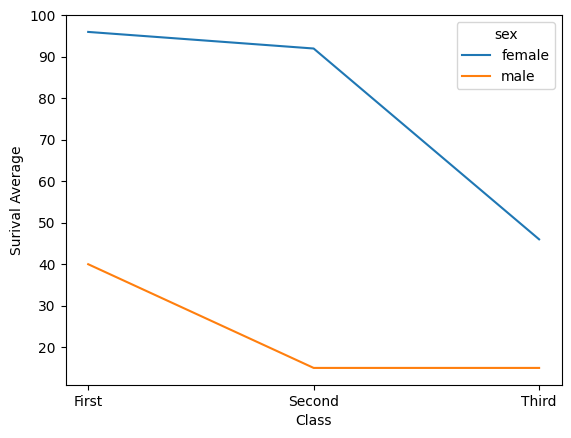

In [525]:
class_and_sex_survival = cleaned_df.groupby(by=["sex", "class"])["survived"]
class_and_sex_survival_average = round(class_and_sex_survival.mean() * 100).reset_index()

print(class_and_sex_survival_average)

sns.lineplot(data=class_and_sex_survival_average, x="class", y="survived", hue="sex")
plt.xlabel("Class")
plt.ylabel("Surival Average")

This line plot further supports the trend of women having a higher survival rate across all classes. 

However, whilst a sharp drop is shown in female surival in third class, men saw no difference in survival percentage. This is likely due to the same trend of women being treated as higher priority. 

In [526]:
cleaned_df["deck"].isnull().value_counts()
cleaned_df = cleaned_df.dropna(subset=["deck"])
cleaned_df["deck"].isnull().value_counts()

deck
False    184
Name: count, dtype: int64

no more null values for deck remain in the dataset, however, a signifcant amount of rows did not contain entries and therefore the result may not be fully accurate since the data pool is now much smaller

  deck  survived
0    A      58.0
1    B      76.0
2    C      59.0
3    D      74.0
4    E      73.0
5    F      64.0
6    G      50.0


Text(0, 0.5, 'Surival Percentage')

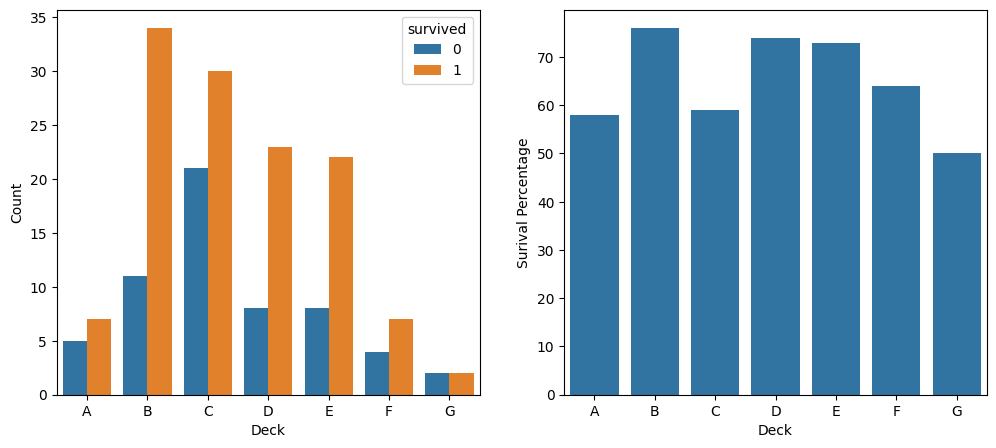

In [527]:
# print(cleaned_df.groupby(by=["deck"])["survived"].value_counts())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

deck_survival_average = round(cleaned_df.groupby(by="deck")["survived"].mean() * 100).reset_index()
print(deck_survival_average)

sns.countplot(data=cleaned_df, x="deck", hue="survived", ax=axes[0])
axes[0].set_xlabel("Deck")
axes[0].set_ylabel("Count")

sns.barplot(data=deck_survival_average, x="deck", y="survived")
axes[1].set_xlabel("Deck")
axes[1].set_ylabel("Surival Percentage")

From the analysis we can see that there is slight variations between survival rate and passenger deck, however, due to the significant missing data, therefore any patterns should be read as caution. 

It could be that different decks had access to different survival mechanisms such as lifeboats or possibly the chance of people further back in the ship having more chance to react and find a suitable escape 

# Conclusion 

From the analysis, a several trends were spotted: 
 - Women had significantly higher survival rates than men,
 - Survival varied by age, younger passengers had higher rates of survival, while the older the passenger the average survival rate dropped,
 - First class passengers were much more likely to survive with 96% of first class female passengers surviving
 - Deck may have impacted survival, however the missing data makes it hard for any significant trends to show

All of the data analysed points to the 2 biggest correlating factors being sex and class. From the analysis, it seems that sex was the most important variable when determining the survival rate, since the difference in second class between male and female significantly favoured females. 